In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
%matplotlib inline

In [3]:
telecom_data=pd.read_csv(r"C:\Users\basav\Downloads\Telco_Customer_Churn_Dataset .csv")

In [4]:
telecom_data.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [5]:
telecom_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
telecom_data.isnull()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7039,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7040,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7041,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [7]:
telecom_data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

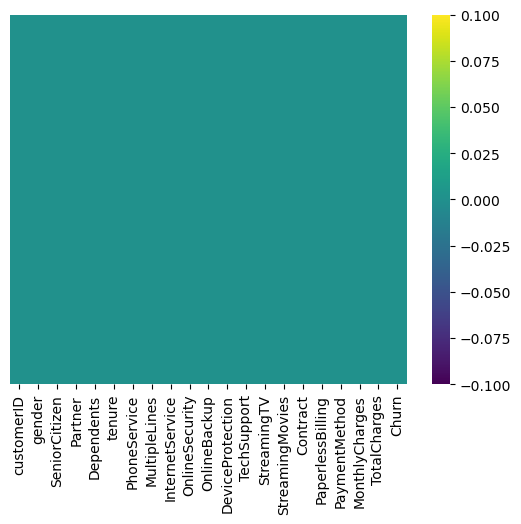

In [8]:
sns.heatmap(telecom_data.isnull(),yticklabels=False,cmap="viridis")
plt.show()

In [9]:
# 📘 TASK 1: DATA CLEANING & PREPROCESSING
# Step 1: Inspect the dataset
print("Dataset shape:", telecom_data.shape)
print("\nColumns:\n", telecom_data.columns)
print("\nMissing values:\n",telecom_data.isnull().sum())

Dataset shape: (7043, 21)

Columns:
 Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [12]:
# Convert 'TotalCharges' to numeric
telecom_data["TotalCharges"] = pd.to_numeric(telecom_data["TotalCharges"], errors="coerce")

# Replace missing values with median safely
telecom_data["TotalCharges"] = telecom_data["TotalCharges"].fillna(telecom_data["TotalCharges"].median())

In [17]:
# Step 3: Drop unnecessary columns
# 'customerID' is just an identifier and not useful for prediction
telecom_data.drop(columns=['customerID'],inplace=True,errors='ignore')

# Step 4: Encode categorical columns
# Convert categorical (object) columns into numeric using One-Hot Encoding
categorical_cols = telecom_data.select_dtypes(include=["object"]).columns
data_encoded = pd.get_dummies(telecom_data, columns=categorical_cols, drop_first=True)

# Step 5: Display final summary
print("\n✅ Data Cleaning Completed Successfully!")
print("New dataset shape:", data_encoded.shape)
print("\nSample cleaned data:\n", data_encoded.head())

# Optional: Save the cleaned data to a new file
data_encoded.to_csv("Cleaned_Telco_Churn.csv", index=False)
print("\n📁 Cleaned dataset saved as 'Cleaned_Telco_Churn.csv'")


✅ Data Cleaning Completed Successfully!
New dataset shape: (7043, 31)

Sample cleaned data:
    SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  StreamingTV_Yes  \
0                            True              False  ...            False   
1         

# 📊 TASK 2: EXPLORATORY DATA ANALYSIS (EDA)

Overall Churn Rate: 26.54%


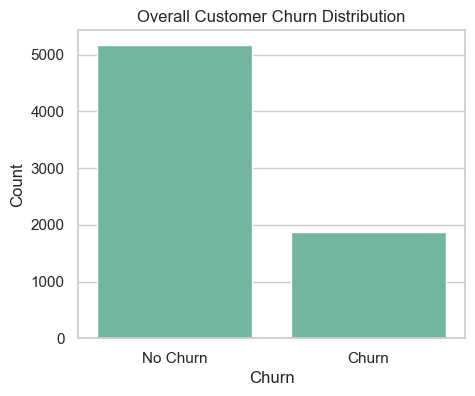

In [18]:
# 📊 TASK 2: EXPLORATORY DATA ANALYSIS (EDA)


# Load cleaned data (if needed)
data = pd.read_csv("Cleaned_Telco_Churn.csv")

# Improve plot style
sns.set(style="whitegrid", palette="Set2")

# ⿡ Overall churn rate
churn_rate = data["Churn_Yes"].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

plt.figure(figsize=(5,4))
sns.countplot(x="Churn_Yes", data=data)
plt.xticks([0,1], ["No Churn", "Churn"])
plt.title("Overall Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

C:\Users\basav\AppData\Local\Temp\ipykernel_17944\4153940150.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(["Female","Male"])
C:\Users\basav\AppData\Local\Temp\ipykernel_17944\4153940150.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels(["No Partner","Partner"])
C:\Users\basav\AppData\Local\Temp\ipykernel_17944\4153940150.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,1].set_xticklabels(["No Dependents","Dependents"])


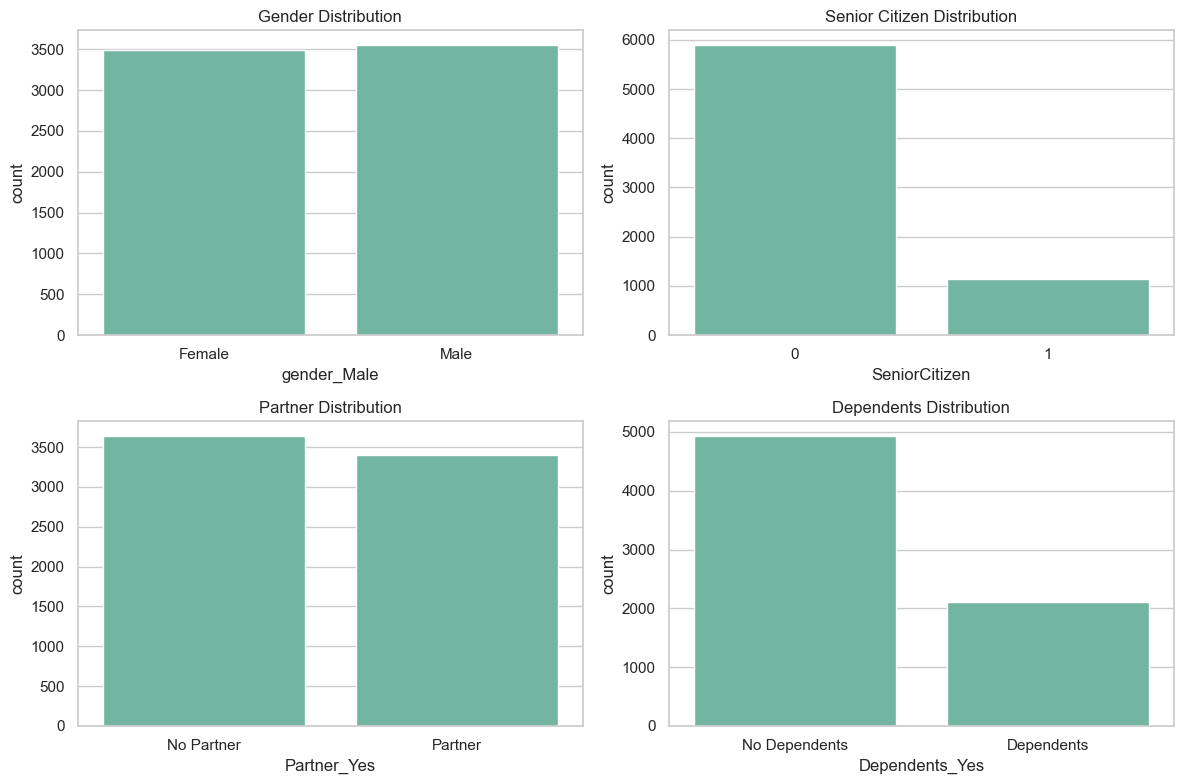

In [19]:
# ⿢ Customer distribution by demographics

fig, axes = plt.subplots(2, 2, figsize=(12,8))
sns.countplot(x="gender_Male", data=data, ax=axes[0,0])
axes[0,0].set_xticklabels(["Female","Male"])
axes[0,0].set_title("Gender Distribution")

sns.countplot(x="SeniorCitizen", data=data, ax=axes[0,1])
axes[0,1].set_title("Senior Citizen Distribution")

sns.countplot(x="Partner_Yes", data=data, ax=axes[1,0])
axes[1,0].set_xticklabels(["No Partner","Partner"])
axes[1,0].set_title("Partner Distribution")

sns.countplot(x="Dependents_Yes", data=data, ax=axes[1,1])
axes[1,1].set_xticklabels(["No Dependents","Dependents"])
axes[1,1].set_title("Dependents Distribution")

plt.tight_layout()
plt.show()



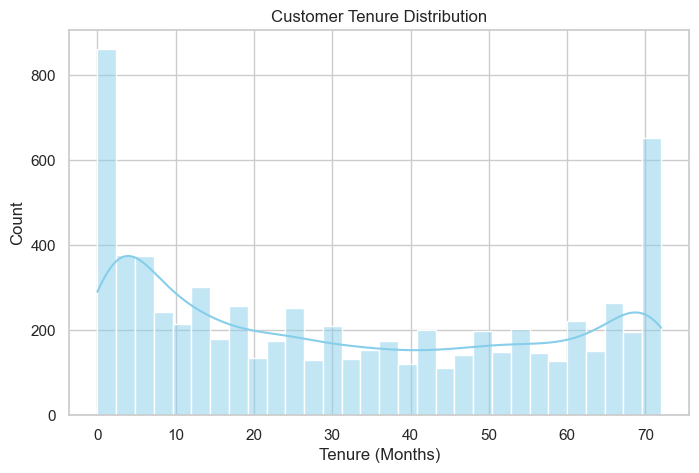

FileNotFoundError: [Errno 2] No such file or directory: 'Telco_Customer_Churn_Dataset.csv'

In [22]:
# ⿣ Tenure distribution
plt.figure(figsize=(8,5))
sns.histplot(data["tenure"], bins=30, kde=True, color="skyblue")
plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Count")
plt.show()

#Relationship between churn & contract/payment type

data_raw = pd.read_csv(r"Telco_Customer_Churn_Dataset.csv")

plt.figure(figsize=(7,4))
sns.countplot(x="Contract", hue="Churn", data=data_raw)
plt.title("Churn by Contract Type")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(7,4))
sns.countplot(x="PaymentMethod", hue="Churn", data=data_raw)
plt.title("Churn by Payment Method")
plt.xticks(rotation=45)
plt.ylable("Count")
plt.show()


Churn Rate by Tenure Group:
TenureGroup
New      47.438243
Mid      25.538793
Loyal    11.929357
Name: Churn_Yes, dtype: float64

Churn Rate by Monthly Charge Group:
ChargeGroup
High      35.477583
Medium    23.649041
Low       10.860774
Name: Churn_Yes, dtype: float64

Churn Rate by Contract Type:
ContractType
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn_Yes, dtype: float64


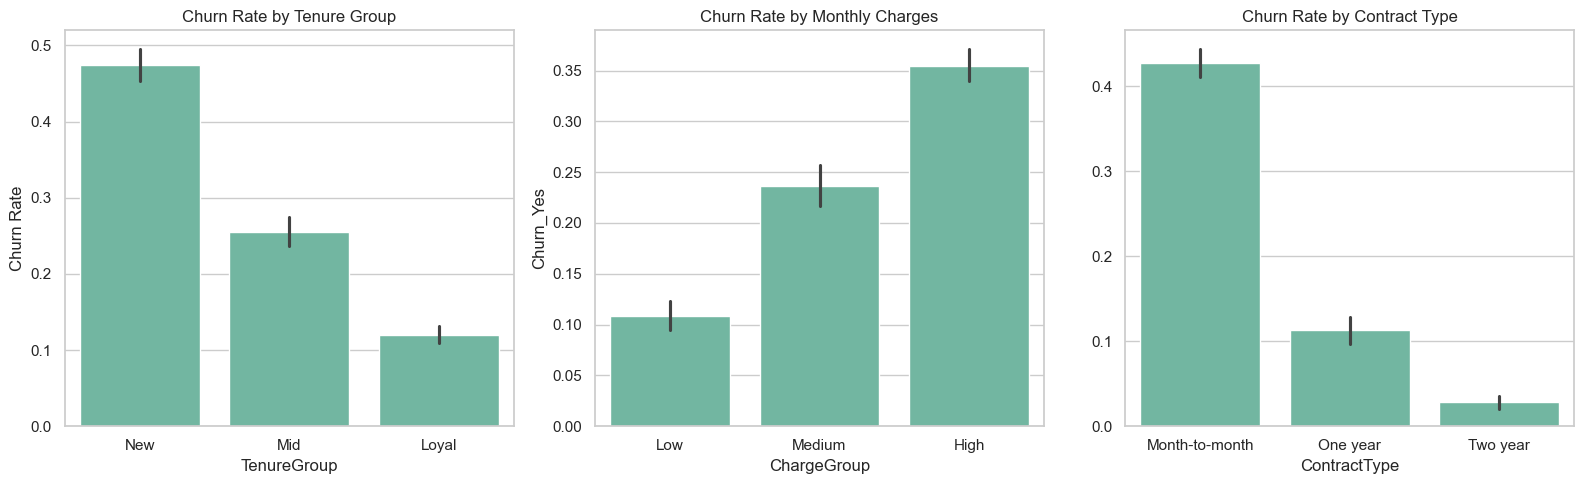

In [23]:
# 🧩 TASK 3: CUSTOMER SEGMENTATION ANALYSIS


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dat
data = pd.read_csv("Cleaned_Telco_Churn.csv")

# Set visualization style
sns.set(style="whitegrid", palette="Set2")

# 1️⃣ Create Tenure Segments
def tenure_group(tenure):
    if tenure <= 12:
        return "New"
    elif tenure <= 36:
        return "Mid"
    else:
        return "Loyal"

data["TenureGroup"] = data["tenure"].apply(tenure_group)

# 2️⃣ Create Monthly Charge Segments

def charges_group(charges):
    if charges < 35:
        return "Low"
    elif charges < 70:
        return "Medium"
    else:
        return "High"

data["ChargeGroup"] = data["MonthlyCharges"].apply(charges_group)

# 3️⃣ Decode Contract Type for readability

data["ContractType"] = (
    data.apply(
        lambda x: "Two year"
        if x["Contract_Two year"] == 1
        else "One year"
        if x["Contract_One year"] == 1
        else "Month-to-month",
        axis=1,
    )
)


# 4️⃣ Analyze churn rates by each segment

def churn_rate_by_group(df, col):
    churn_rates = (
        df.groupby(col)["Churn_Yes"].mean().sort_values(ascending=False) * 100
    )
    return churn_rates

# Tenure
print("\nChurn Rate by Tenure Group:")
print(churn_rate_by_group(data, "TenureGroup"))

# Monthly Charges
print("\nChurn Rate by Monthly Charge Group:")
print(churn_rate_by_group(data, "ChargeGroup"))

# Contract Type
print("\nChurn Rate by Contract Type:")
print(churn_rate_by_group(data, "ContractType"))


# 5️⃣ Visualize the results

fig, axes = plt.subplots(1, 3, figsize=(16,5))

sns.barplot(x="TenureGroup", y="Churn_Yes", data=data, ax=axes[0])
axes[0].set_title("Churn Rate by Tenure Group")
axes[0].set_ylabel("Churn Rate")

sns.barplot(x="ChargeGroup", y="Churn_Yes", data=data, ax=axes[1])
axes[1].set_title("Churn Rate by Monthly Charges")

sns.barplot(x="ContractType", y="Churn_Yes", data=data, ax=axes[2])
axes[2].set_title("Churn Rate by Contract Type")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

C:\Users\basav\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


📊 Model Performance Summary
Accuracy : 0.804
Precision: 0.654
Recall   : 0.556
F1 Score : 0.601


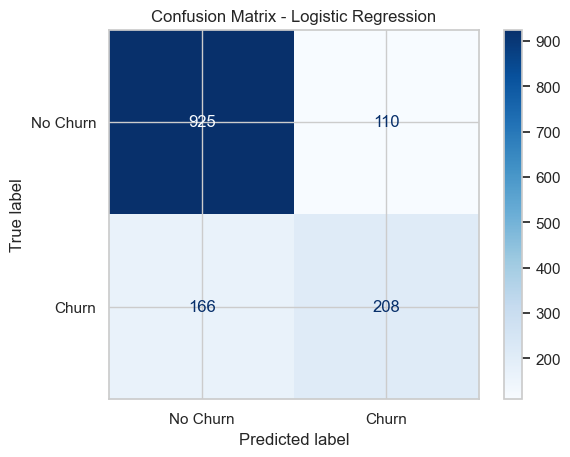

In [25]:
# ---------------------------------------------
# 🤖 TASK 4: CHURN PREDICTION MODEL
# ---------------------------------------------

# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

# 1️⃣ Load the cleaned data

data = pd.read_csv("Cleaned_Telco_Churn.csv")

# 2️⃣ Define features (X) and target (y)

X = data.drop("Churn_Yes", axis=1)
y = data["Churn_Yes"]

# 3️⃣ Split into Train/Test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# 4️⃣ Train Logistic Regression Model

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


# 5️⃣ Make Predictions

y_pred = model.predict(X_test)


# 6️⃣ Evaluate Performance

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("📊 Model Performance Summary")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1 Score : {f1:.3f}")


# 7️⃣ Confusion Matrix Visualization

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [27]:
# 💼 TASK 5: CUSTOMER RETENTION STRATEGIES & INSIGHTS

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Load cleaned data
data = pd.read_csv("Cleaned_Telco_Churn.csv")

# 1️⃣ Feature Importance

X = data.drop("Churn_Yes", axis=1)
y = data["Churn_Yes"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Create DataFrame of feature importance (coefficients)
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.coef_[0]
}).sort_values(by="Importance", ascending=False)

print("📊 Top Factors Influencing Churn:")
print(feature_importance.head(10))

# 2️⃣ Customer Lifetime Value (LTV)

# Approximation formula: LTV = MonthlyCharges * Tenure
data["LTV"] = data["MonthlyCharges"] * data["tenure"]

print("\n💰 Average Customer LTV:", round(data["LTV"].mean(), 2))


# 3️⃣ Identify High-Value Customers at Risk

# Define thresholds
ltv_threshold = data["LTV"].quantile(0.75)  # Top 25% value customers
high_value_customers = data[data["LTV"] > ltv_threshold]
high_value_churn = high_value_customers[high_value_customers["Churn_Yes"] == 1]

print(f"\n⚠ High-value customers at risk of churn: {len(high_value_churn)}")
print(high_value_churn[["tenure", "MonthlyCharges", "LTV"]].head())

# 4️⃣ Summary Insights (print recommendations)

print("\n📈 Recommendations to Reduce Churn:")
print("""
1. 🔁 Offer loyalty rewards for 'Month-to-month' and 'New' tenure customers.
2. 💳 Provide discounts or bundle offers for high 'MonthlyCharges' customers.
3. 📞 Improve customer support and tech assistance — low 'TechSupport_Yes' correlates with higher churn.
4. 🧾 Encourage customers to move from 'Month-to-month' → 'One year' or 'Two year' contracts.
5. 💼 Monitor high-value customers (top 25% LTV) for early warning signs and personalized offers.
""")

📊 Top Factors Influencing Churn:
                           Feature  Importance
10     InternetService_Fiber optic    0.745562
28  PaymentMethod_Electronic check    0.382246
26            PaperlessBilling_Yes    0.380137
9                MultipleLines_Yes    0.275875
21                 StreamingTV_Yes    0.195380
23             StreamingMovies_Yes    0.193789
8   MultipleLines_No phone service    0.166783
0                    SeniorCitizen    0.148097
29      PaymentMethod_Mailed check    0.064568
5                      Partner_Yes    0.024842

💰 Average Customer LTV: 2279.58

⚠ High-value customers at risk of churn: 255
     tenure  MonthlyCharges      LTV
13       49          103.70  5081.30
26       47           99.35  4669.45
104      68          110.00  7480.00
110      55           96.75  5321.25
173      53           94.85  5027.05

📈 Recommendations to Reduce Churn:

1. 🔁 Offer loyalty rewards for 'Month-to-month' and 'New' tenure customers.
2. 💳 Provide discounts or bundle off

C:\Users\basav\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


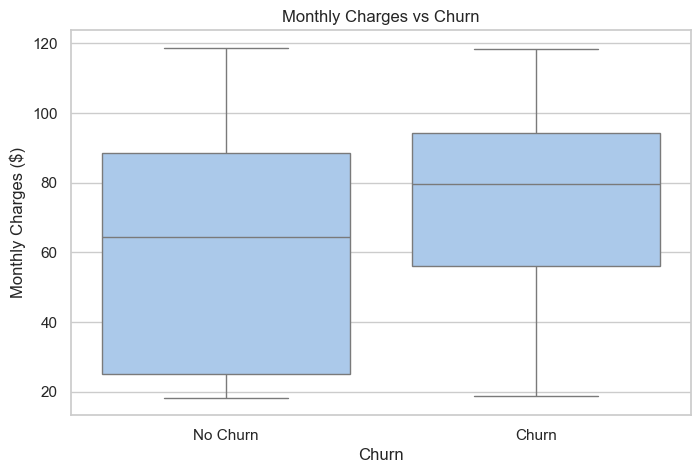

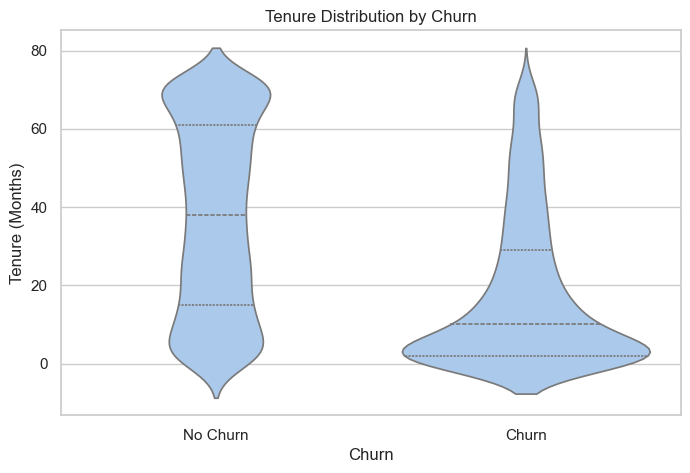

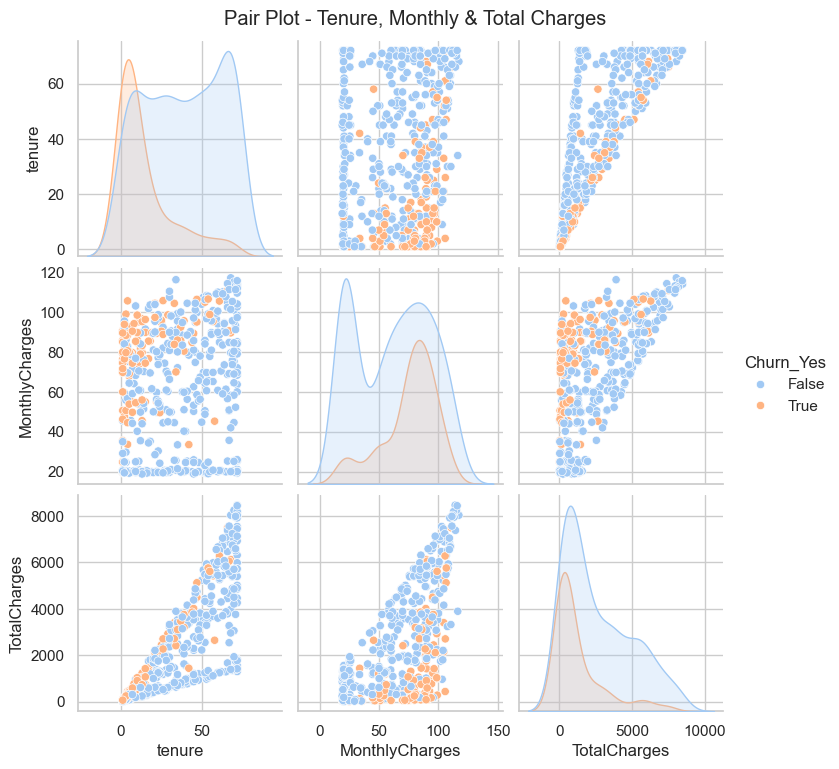

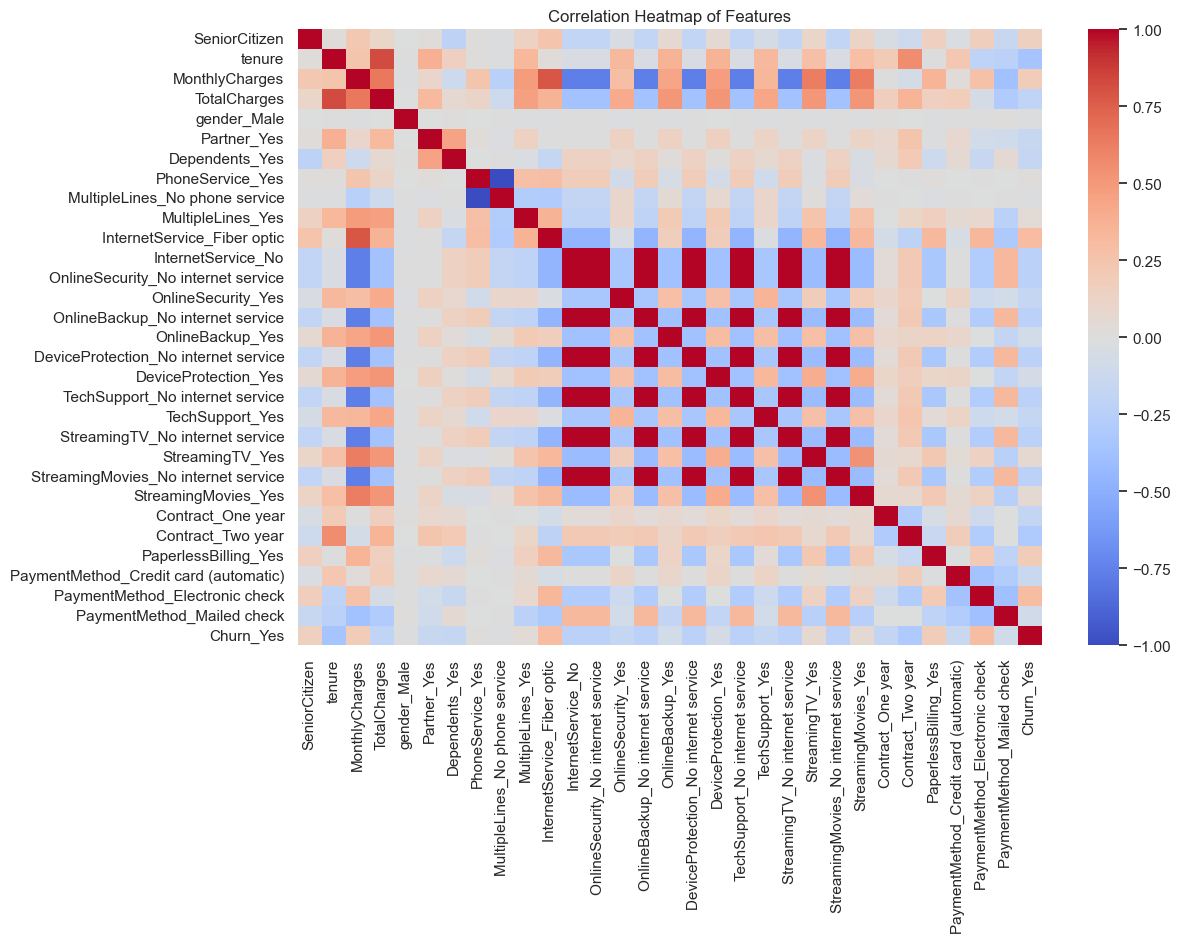

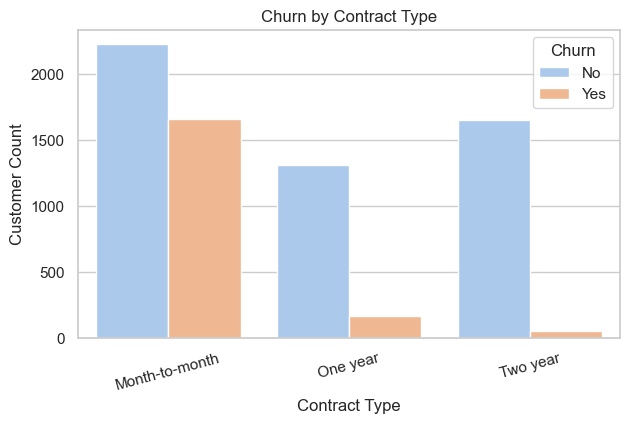

In [29]:
# 📊 TASK 6: DATA VISUALIZATION FOR CUSTOMER CHURN


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
data = pd.read_csv("Cleaned_Telco_Churn.csv")

# Set Seaborn style
sns.set(style="whitegrid", palette="pastel")

# 1️⃣ Box Plot: Tenure vs MonthlyCharges by Churn
plt.figure(figsize=(8, 5))
sns.boxplot(x="Churn_Yes", y="MonthlyCharges", data=data)
plt.xticks([0, 1], ["No Churn", "Churn"])
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges ($)")
plt.show()

# 2️⃣ Violin Plot: Tenure Distribution by Churn

plt.figure(figsize=(8, 5))
sns.violinplot(x="Churn_Yes", y="tenure", data=data, inner="quartile")
plt.xticks([0, 1], ["No Churn", "Churn"])
plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()


# 3️⃣ Pair Plot: Tenure, MonthlyCharges, TotalCharges

sampled = data.sample(500, random_state=42)  # sample for faster plotting
sns.pairplot(sampled, vars=["tenure", "MonthlyCharges", "TotalCharges"], hue="Churn_Yes")
plt.suptitle("Pair Plot - Tenure, Monthly & Total Charges", y=1.02)
plt.show()

# 4️⃣ Correlation Heatmap

plt.figure(figsize=(12, 8))
corr = data.corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Features")
plt.show()


# 5️⃣ Count Plot: Contract Type vs Churn

# Recreate contract column for better readability
data["ContractType"] = (
    data.apply(
        lambda x: "Two year"
        if x["Contract_Two year"] == 1
        else "One year"
        if x["Contract_One year"] == 1
        else "Month-to-month",
        axis=1,
    )
)

plt.figure(figsize=(7, 4))
sns.countplot(x="ContractType", hue="Churn_Yes", data=data)
plt.xticks(rotation=15)
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Customer Count")
plt.legend(title="Churn", labels=["No", "Yes"])
plt.show()